# 04 - Medium Term Modeling

This notebook reviews the one month daily forecast model. It reads the saved daily metrics, validation predictions, final forecasts, and model file created by the pipeline.

The daily task is different from the half-hourly task. We are forecasting one value per day for each ACORN segment, so the model needs to capture broader weather and weekly patterns rather than peaks within the days.

## Setup

In [11]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

try:
    from IPython.display import display
except ImportError:
    display = None


def show_plot(fig):
    if display is not None:
        display(fig)
    plt.close(fig)

metrics_path = ROOT / "outputs" / "group5" / "metrics" / "validation_metrics.csv"
valid_path = ROOT / "outputs" / "group5" / "metrics" / "validation_predictions_daily.csv"
forecast_path = ROOT / "outputs" / "group5" / "predictions" / "group_5_daily_predict.csv"
model_path = ROOT / "models" / "medium_term" / "group5_daily_selected.joblib"

print("Run the pipeline first if these files are missing:")
print("EI-climat/bin/python scripts/group5_run_pipeline.py")

Run the pipeline first if these files are missing:
EI-climat/bin/python scripts/group5_run_pipeline.py


## Validation metrics

The table compares baselines and learned models on a later historical validation period. We are using the same time aware principle used for the short term model.

For the daily horizon, we care about whether the model improves on recent history baselines without overfitting the smaller daily dataset.

In [12]:
metrics = pd.read_csv(metrics_path)
daily_metrics = metrics[metrics["frequency"] == "daily"].sort_values(["acorn", "rmse"])
daily_metrics

,frequency,model,acorn,rmse,n
37,daily,gradient_boosting,ACORN-E,0.417996,31
33,daily,ridge,ACORN-E,0.420502,31
21,daily,previous_day,ACORN-E,0.488096,31
25,daily,previous_week,ACORN-E,0.576484,31
29,daily,seasonal_mean,ACORN-E,1.857962,31
34,daily,ridge,ACORN-F,0.424276,31
38,daily,gradient_boosting,ACORN-F,0.457392,31
26,daily,previous_week,ACORN-F,0.494960,31
22,daily,previous_day,ACORN-F,0.554479,31
30,daily,seasonal_mean,ACORN-F,1.601140,31


The selected medium term model is the ridge regression model, it performs best on the validation split. This is a good fit for the daily task because the dataset has fewer rows than the half-hourly task.

## Validation curve for one segment

This plot compares real and predicted daily consumption for ACORN-E on the validation period. It checks whether the model follows the direction and level of the daily series.


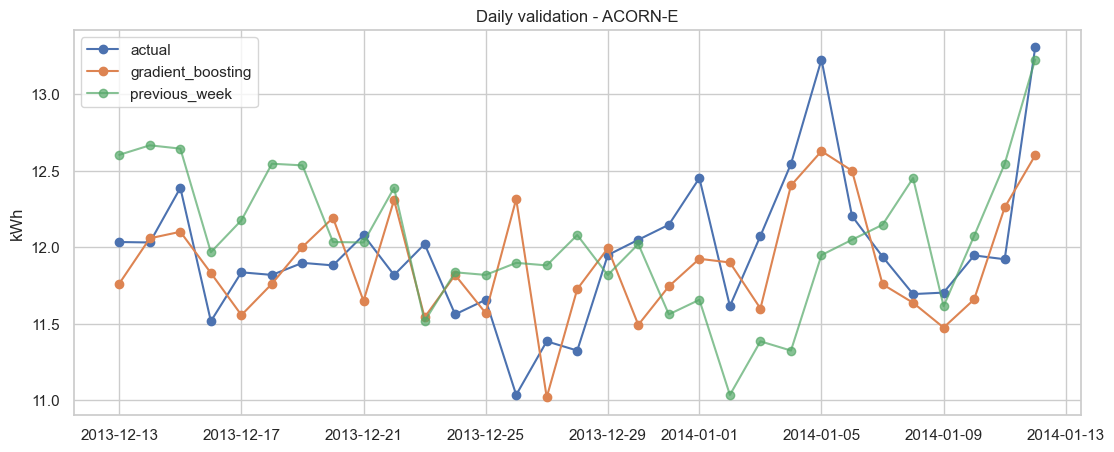

In [13]:
valid = pd.read_csv(valid_path, parse_dates=["timestamp"])
acorn = "ACORN-E"
plot_df = valid[valid["Acorn"] == acorn].copy()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(plot_df["timestamp"], plot_df["actual"], marker="o", label="actual")
ax.plot(plot_df["timestamp"], plot_df["gradient_boosting"], marker="o", label="gradient_boosting")
ax.plot(plot_df["timestamp"], plot_df["previous_week"], marker="o", label="previous_week", alpha=0.7)
ax.set_title(f"Daily validation - {acorn}")
ax.set_ylabel("kWh")
ax.legend()
show_plot(fig)

The daily model tracks the main movement of the series, but it doesn't match every day exactly. That is acceptable for this horizon as long as the forecast level and trend are realistic.

## Final one month forecast

The final daily forecast covers 2014-01-13 until 2014-02-13. We plot all three segments to compare their expected levels over the month.


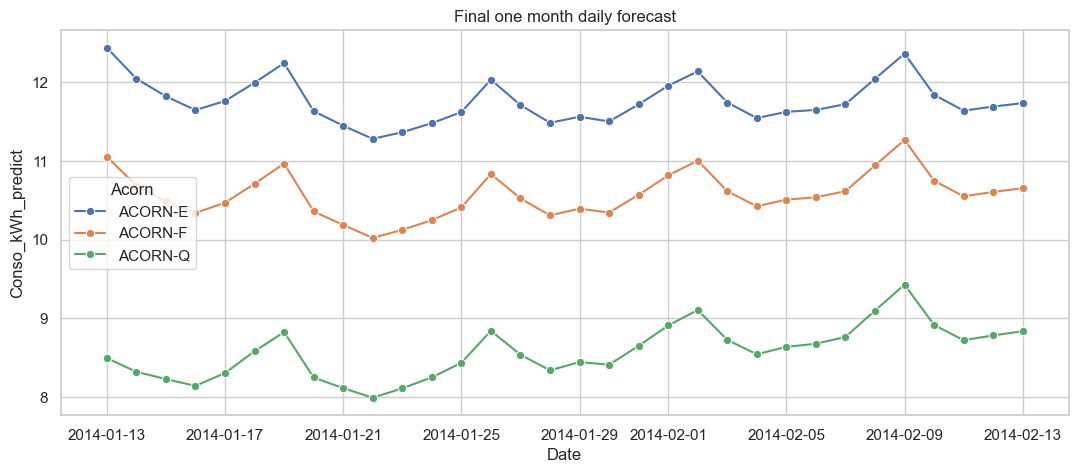

,Acorn,Date,Conso_kWh_predict
0,ACORN-E,2014-01-13,12.436522
1,ACORN-E,2014-01-14,12.044490
2,ACORN-E,2014-01-15,11.819349
3,ACORN-E,2014-01-16,11.645198
4,ACORN-E,2014-01-17,11.760733


In [14]:
forecast = pd.read_csv(forecast_path, parse_dates=["Date"])
fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=forecast, x="Date", y="Conso_kWh_predict", hue="Acorn", marker="o", ax=ax)
ax.set_title("Final one month daily forecast")
show_plot(fig)

forecast.head()

The final forecast keeps the same segment ordering seen in the data, ACORN-E is highest, ACORN-F is in the middle, and ACORN-Q is lowest. The month is in winter, so temperature is important.

## Saved model check

In [15]:
print("Saved medium-term model:", model_path)
print("Exists:", model_path.exists())

Saved medium-term model: c:\Users\ignac\Desktop\CS\Consumo electrico\ei-climat\models\medium_term\group5_daily_selected.joblib
Exists: True
